
=== ID3 (Entropy) ===
Accuracy: 0.875
              precision    recall  f1-score   support

       Small       0.67      1.00      0.80         2
      Medium       1.00      0.67      0.80         3
       Large       1.00      1.00      1.00         3

    accuracy                           0.88         8
   macro avg       0.89      0.89      0.87         8
weighted avg       0.92      0.88      0.88         8



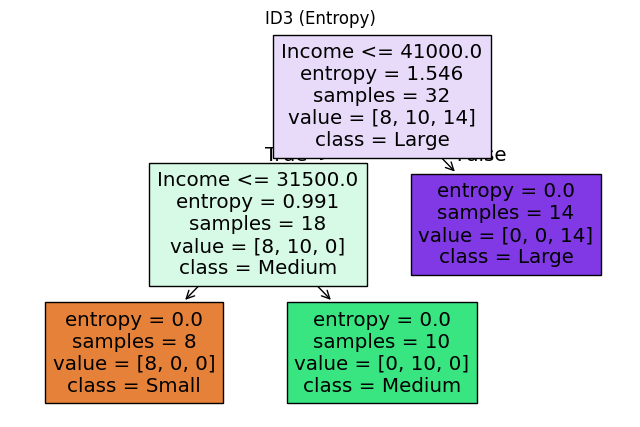


=== CART (Gini) ===
Accuracy: 0.875
              precision    recall  f1-score   support

       Small       0.67      1.00      0.80         2
      Medium       1.00      0.67      0.80         3
       Large       1.00      1.00      1.00         3

    accuracy                           0.88         8
   macro avg       0.89      0.89      0.87         8
weighted avg       0.92      0.88      0.88         8



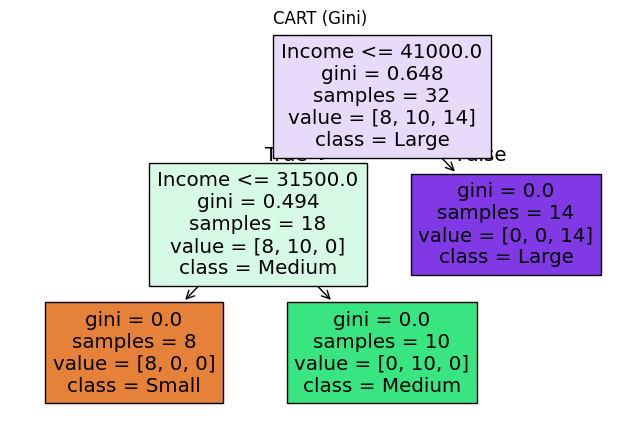

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("loan_data.csv")

# Create target
loan = df["LoanAmount"]
df["LoanClass"] = np.select(
    [loan < 10000, (loan >= 10000) & (loan < 20000), loan >= 20000],
    [0, 1, 2]
)

# Features / target
X = df[["CreditScore","Income","EmploymentYears"]]
y = df["LoanClass"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Common function
def run_model(name, criterion):
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=["Small","Medium","Large"]))

    plt.figure(figsize=(8,5))
    plot_tree(model, feature_names=X.columns,
              class_names=["Small","Medium","Large"], filled=True)
    plt.title(name)
    plt.show()

# Run both
run_model("ID3 (Entropy)", "entropy")
run_model("CART (Gini)", "gini")